Link to the learning path:
https://chatgpt.com/c/6916461a-e3a8-8330-be9d-1f5dd0cc84c5

# 1. Implement the Linear Regression model with Gradient Descent

In [28]:
import numpy as np
#Define the model class
class LinearRegressionGD:
  # we use default values for learning_rate and number of iteration
  def __init__(self, learning_rate = 0.01, n_iteration = 1000):
    self.learning_rate = learning_rate
    self.n_iteration = n_iteration
    self.weight = None
    self.bias = None
    self.loss_history = []

  # Training the model
  def fit(self, X, y):
    """
      X: shape (n_samples, n_features)
      y: shape (n_samples,)
    """
    X = np.array(X, dtype = float)
    y = np.array(y, dtype = float)
    n_samples, n_features = X.shape

    # initialize weight and bias
    self.weight = np.zeros(n_features)
    self.bias = 0.0

    # start GD loop
    for _ in range(self.n_iteration):
      y_pred = np.dot(X,self.weight) + self.bias
      # compute gradients
      error = y_pred - y
      d_weight= (1/n_samples)* np.dot(X.T, error)
      d_bias = (1/n_samples) * np.sum(error)

      # GD update
      self.weight = self.weight - self.learning_rate * d_weight
      self.bias = self.bias - self.learning_rate * d_bias

      # compute and store cost (MSE: mean of squared error)
      cost = (1/(2* n_samples)) * np.sum(error ** 2)
      self.loss_history.append(cost)

  # predicting the model
  # this uses the learned weight and bias to compute the predictions
  def predict (self, X):
    X = np.array(X, dtype = float)
    return np.dot(X, self.weight) + self.bias

We’re faking some data that approximately follows the line:

𝑦 = 3𝑥 + 4

with a bit of randomness (“noise”) added


X is 100 random x-values, each between 0 and 2

X has shape (100, 1)

X[:, 0] means: "take all rows, column 0"

That gives a 1D array of shape (100,) instead of (100,1), which is handy for y.

3 * X[:, 0] + 4

weights:  [3.13824205]
bias:  4.090735418913156


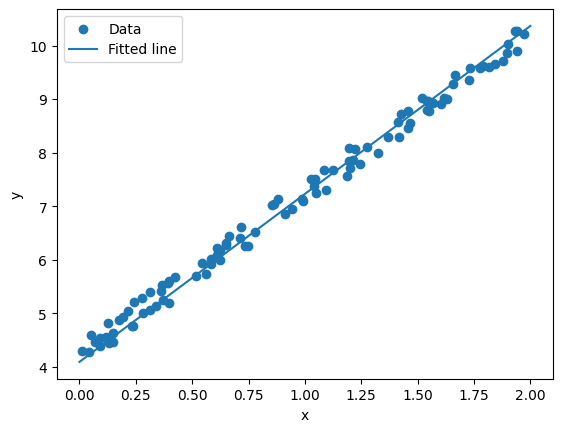

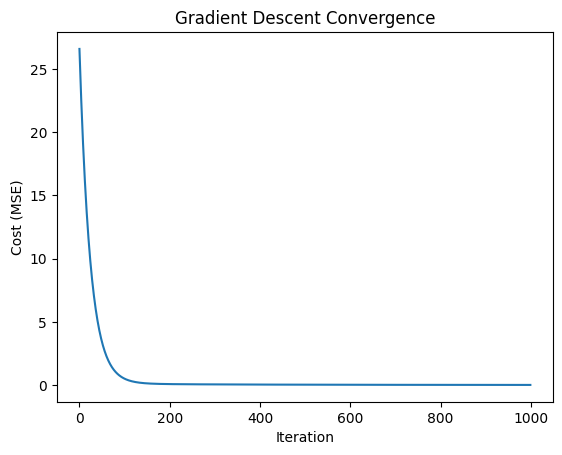

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# dataset : y = 3x+4+ noise
np.random.seed(42)

# for one feature
X = 2 * np.random.rand(100,1)
y = 3 * X[:,0] + 4 + np.random.rand(100) * 0.5

# Train the model
model = LinearRegressionGD (learning_rate = 0.01, n_iteration = 1000)
model.fit(X,y)

print("weights: ", model.weight)
print("bias: ", model.bias)

# make a prediction for smooth line
X_new = np.linspace(0,2,100).reshape(-1,1)
# or X_new = np.aragne(0,2,0.02).reshape(-1,1)
y_pred = model.predict(X_new)



# plot the data and the learned line
plt.scatter(X, y, label="Data") # to plot dots
plt.plot(X_new, y_pred, label = "Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# plot loss curve
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

X = np.array(X, dtype = float)
y = np.array(y, dtype = float)

Converts X and y into numpy arrays.

Gets number of samples and features.

Example: if X has shape (100, 1), then:

100 samples (rows)

1 feature (column)

python convention:
 a, b = (100, 1)
Python automatically assigns:
a = 100 and b = 1

X_new = np.linspace(0,2,100).reshape(-1,1)

creates 100 numbers in range (0,2)



reshape(-1, 10)
NumPy automatically finds the correct number of rows, no matter how large the input is.

example: a = np.arange(50)
a.reshape(-1, 10)
total = 50

columns = 10

rows = 50 ÷ 10 = 5

So shape becomes (5, 10).

#2. Multiple Linear Regression or Linear Regression with multiple features

weights:  [2.77903703 3.88868656]
bias:  4.747610290943666


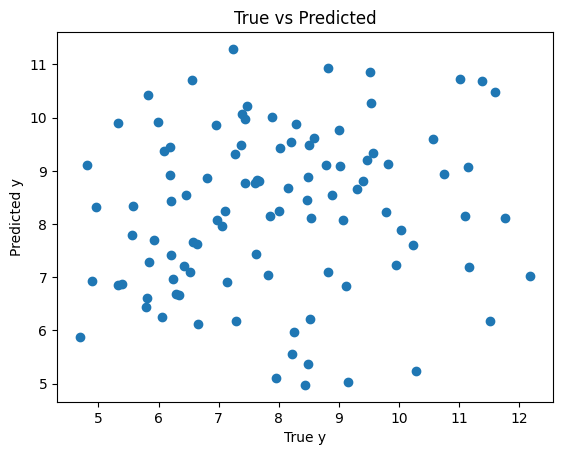

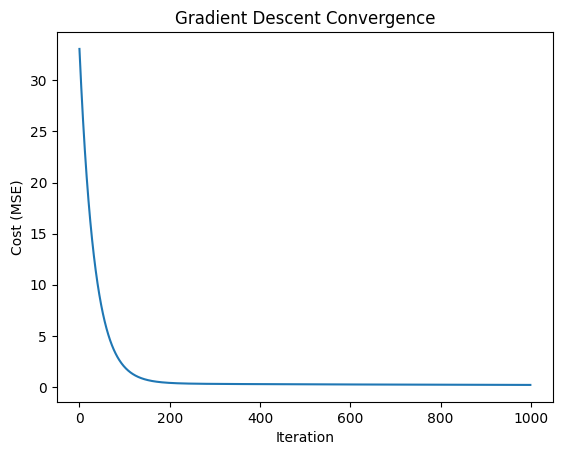

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# dataset : y = 3x+4+ noise
np.random.seed(42)

# for multiple features
X = np.random.rand(100, 2)   # 2 features
# Example true model: y = 3*x1 + 5*x2 + 4 + noise
y = 3*X[:,0] + 5*X[:,1] + 4 + np.random.randn(100)*0.5


# Train the model
model = LinearRegressionGD (learning_rate = 0.01, n_iteration = 1000)
model.fit(X,y)

print("weights: ", model.weight)
print("bias: ", model.bias)

# make a prediction for smooth line

# for multiple features
X_new = np.random.rand(100, 2)
y_pred = model.predict(X_new)



# plot the data and the learned line
plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted")
plt.show()

# plot loss curve
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

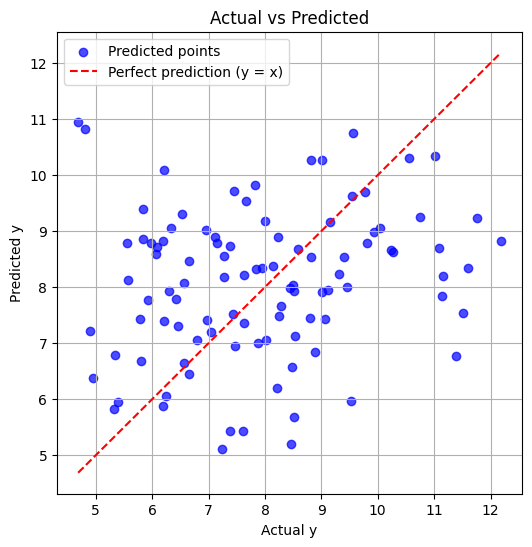

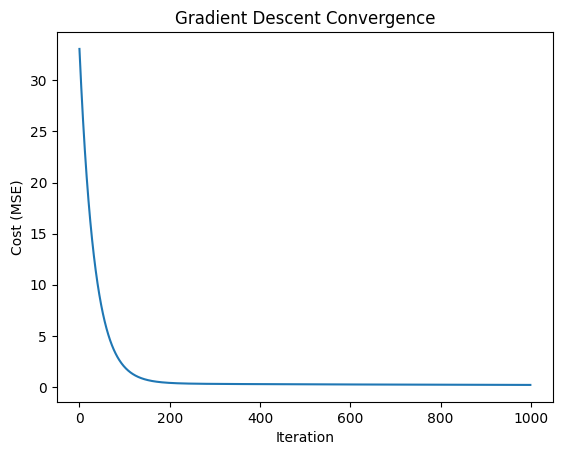

In [37]:
# predictions
X_new = np.random.rand(100, 2)
y_pred = model.predict(X_new)

# Plot actual vs predicted
plt.figure(figsize=(6, 6))

# Predicted points
plt.scatter(y, y_pred, color="blue", alpha=0.7, label="Predicted points")

# Perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", label="Perfect prediction (y = x)")

plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

# plot loss curve
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

weights:  [2.02719381 3.18462994]
bias:  4.725912579221547


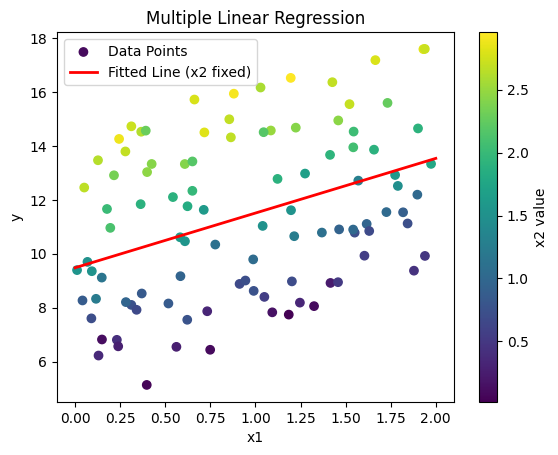

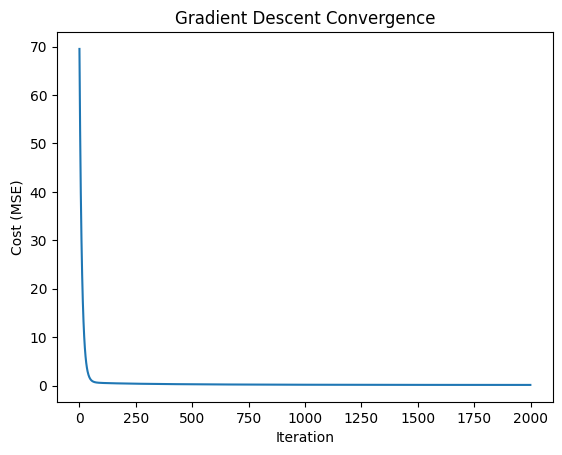

In [38]:

import numpy as np
import matplotlib.pyplot as plt

# ---------- Dataset: y = 2*x1 + 3*x2 + 5 + noise ----------
np.random.seed(42)

# Two features
x1 = 2 * np.random.rand(100)
x2 = 3 * np.random.rand(100)

# Stack into shape (100, 2)
X = np.column_stack((x1, x2))

# Generate target
noise = np.random.randn(100) * 0.5
y = 2 * x1 + 3 * x2 + 5 + noise    # true model

# ---------- Train the model ----------
model = LinearRegressionGD(learning_rate=0.01, n_iteration=2000)
model.fit(X, y)

print("weights: ", model.weight)
print("bias: ", model.bias)

# ---------- Prediction ----------
# Create a grid for visualization (fix x2, vary x1 OR fix x1, vary x2)
# Here: vary x1 from 0–2 while keeping x2 fixed at its mean
x1_new = np.linspace(0, 2, 100)
x2_fixed = np.full(100, np.mean(x2))

X_new = np.column_stack((x1_new, x2_fixed))
y_pred = model.predict(X_new)

# ---------- Plot ----------
# Scatter plot: we color by x2 to show 2D data better
plt.scatter(x1, y, c=x2, cmap='viridis', label="Data Points")
plt.plot(x1_new, y_pred, color="red", linewidth=2, label="Fitted Line (x2 fixed)")

plt.xlabel("x1")
plt.ylabel("y")
plt.title("Multiple Linear Regression")
plt.legend()
plt.colorbar(label="x2 value")  # show how x2 changes
plt.show()

# ---------- Loss Curve ----------
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()


# 3. Implement the Linear Regression and Ridge regularization with GD

In [23]:
class LinearRegressionL2:
    def __init__(self, learning_rate=0.01, n_iters=1000, lambda_=0.1):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_  # regularization strength
        self.weight = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n_samples, n_features = X.shape

        self.weight = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weight) + self.bias
            error = y_pred - y

            # L2 gradients
            dweight = (1 / n_samples) * np.dot(X.T, error) + (self.lambda_ / n_samples) * self.weight
            dbias = (1 / n_samples) * np.sum(error)

            self.weight -= self.learning_rate * dweight
            self.bias -= self.learning_rate * dbias

            # L2-regularized cost
            mse = (1 / (2 * n_samples)) * np.sum(error ** 2)
            l2_penalty = (self.lambda_ / (2 * n_samples)) * np.sum(self.weight ** 2)
            cost = mse + l2_penalty
            self.loss_history.append(cost)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.dot(X, self.weight) + self.bias


weights:  [3.13060671]
bias:  4.097658734604584


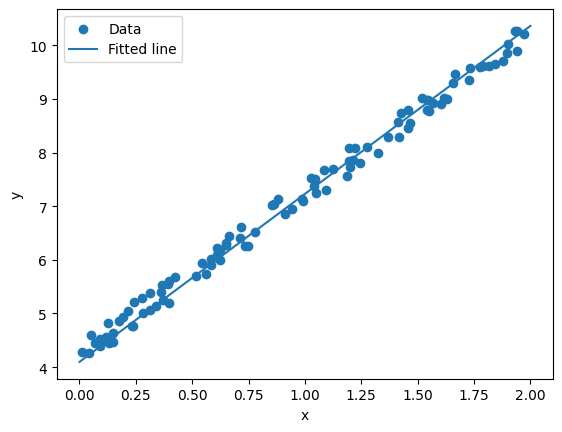

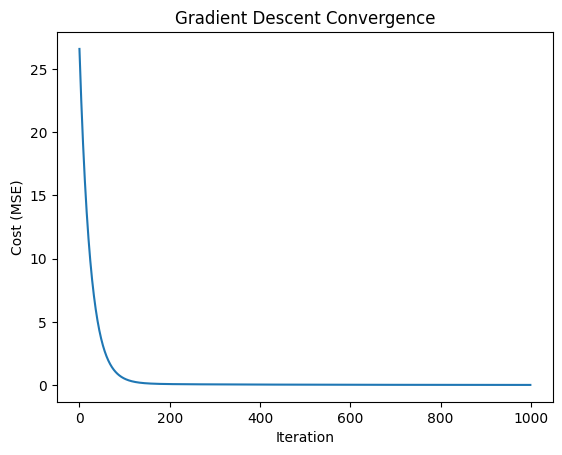

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# dataset : y = 3x+4+ noise
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 3 * X[:,0] + 4 + np.random.rand(100) * 0.5

# Train the model
model = LinearRegressionL2 (learning_rate = 0.01, n_iters = 1000, lambda_ = 0.1)
model.fit(X,y)

print("weights: ", model.weight)
print("bias: ", model.bias)

# make a prediction for smooth line
X_new = np.linspace(0,2,100).reshape(-1,1)
# or X_new = np.aragne(0,2,0.02).reshape(-1,1)
y_pred = model.predict(X_new)

# plot the data and the learned line
plt.scatter(X, y, label="Data") # to plot dots
plt.plot(X_new, y_pred, label = "Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# plot loss curve
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

# 4. Implement the Linear Regression and Lasso regularization with GD

In [26]:
class LinearRegressionL1:
    def __init__(self, learning_rate=0.01, n_iters=1000, lambda_=0.1):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_
        self.weight = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n_samples, n_features = X.shape

        self.weight = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weight) + self.bias
            error = y_pred - y

            # Basic gradient of MSE
            dweight = (1 / n_samples) * np.dot(X.T, error)
            dbias = (1 / n_samples) * np.sum(error)

            # Add L1 term: lambda * sign(weight)
            dweight += (self.lambda_ / n_samples) * np.sign(self.weight)

            # Gradient descent update
            self.weight -= self.learning_rate * dweight
            self.bias -= self.learning_rate * dbias

            # L1-regularized cost
            mse = (1 / (2 * n_samples)) * np.sum(error ** 2)
            l1_penalty = (self.lambda_ / n_samples) * np.sum(np.abs(self.weight))
            cost = mse + l1_penalty
            self.loss_history.append(cost)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.dot(X, self.weight) + self.bias


weights:  [3.13586169]
bias:  4.092882890062621


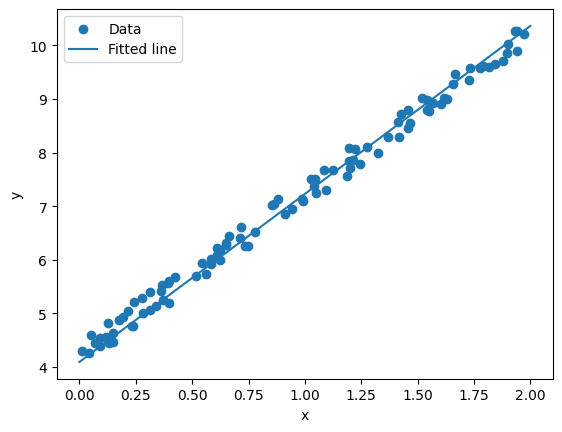

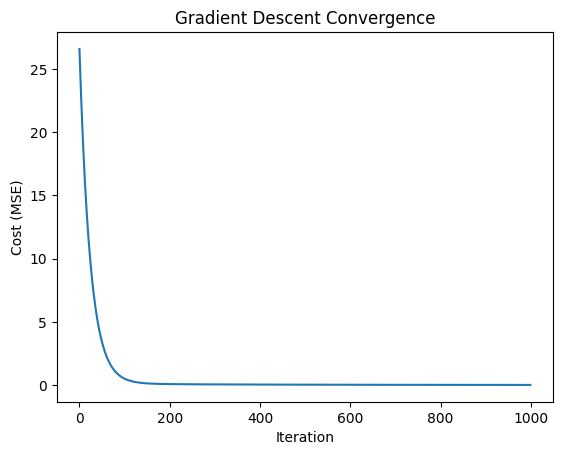

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# dataset : y = 3x+4+ noise
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 3 * X[:,0] + 4 + np.random.rand(100) * 0.5

# Train the model
model = LinearRegressionL1 (learning_rate = 0.01, n_iters = 1000, lambda_ = 0.1)
model.fit(X,y)

print("weights: ", model.weight)
print("bias: ", model.bias)

# make a prediction for smooth line
X_new = np.linspace(0,2,100).reshape(-1,1)
# or X_new = np.aragne(0,2,0.02).reshape(-1,1)
y_pred = model.predict(X_new)

# plot the data and the learned line
plt.scatter(X, y, label="Data") # to plot dots
plt.plot(X_new, y_pred, label = "Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# plot loss curve
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

# 5. Implement Linear Regression with Scikit-Learn (Multiple Features)

Weights (coefficients): [1.91456867 3.11988524]
Bias (intercept): 4.955305018225033


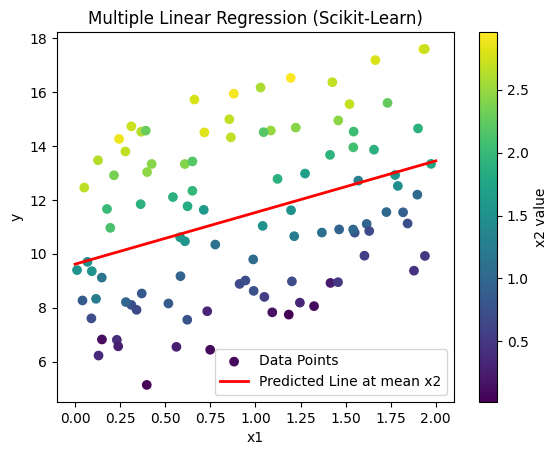

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---------- Dataset: y = 2*x1 + 3*x2 + 5 + noise ----------
np.random.seed(42)

# Two features
x1 = 2 * np.random.rand(100)
x2 = 3 * np.random.rand(100)

# Combine features into shape (100, 2)
X = np.column_stack((x1, x2))

# Target variable
noise = np.random.randn(100) * 0.5
y = 2 * x1 + 3 * x2 + 5 + noise

# ---------- Train the scikit-learn linear regression model ----------
model = LinearRegression()
model.fit(X, y)

print("Weights (coefficients):", model.coef_)   # [2, 3]
print("Bias (intercept):", model.intercept_)     # ~5

# ---------- Make predictions ----------
# For visualization: vary x1, fix x2 at its mean
x1_new = np.linspace(0, 2, 100)
x2_fixed = np.full(100, np.mean(x2))
X_new = np.column_stack((x1_new, x2_fixed))

y_pred = model.predict(X_new)

# ---------- Plot ----------
plt.scatter(x1, y, c=x2, cmap='viridis', label="Data Points")
plt.plot(x1_new, y_pred, color="red", linewidth=2, label="Predicted Line at mean x2")

plt.xlabel("x1")
plt.ylabel("y")
plt.title("Multiple Linear Regression (Scikit-Learn)")
plt.legend()
plt.colorbar(label="x2 value")
plt.show()
